In [3]:
import heapq
import sys

import matplotlib
import matplotlib.pyplot as plt

IS_FILE_INPUT = True
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False


def prim(G: dict[int, list[tuple[int, int]]]) -> list[tuple[int, int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(G.keys())
    ans: list[tuple[int, int]] = []
    used = {v: False for v in v_list}

    pre = v_list[0]
    used[pre] = True
    que = [(cost, v) for v, cost in G[pre]]
    heapq.heapify(que)
    while que:
        cost_v, v = heapq.heappop(que)
        if used[v]:
            continue
        used[v] = True
        ans.append((min(pre, v), max(pre, v)))
        pre = v
        for nxt, cost_nxt in G[v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, nxt))
    return ans


class Env:
    def __init__(self, input_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(list(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [[(l + r) / 2, (c + d) / 2] for l, r, c, d in rectangles]
        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
        output_file_path: str,
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"

        with open(output_file_path, "w") as f:
            for query_str in self._query_history:
                f.write(query_str + "\n")
            f.write(ans_str)

    def _input(self):
        W, D, N = map(int, input().split())
        a = []
        for d in range(D):
            a.append(list(map(int, input().split())))
        return W, D, N, a


def solve(env: Env):
    N, M, Q, L, W = env.N, env.M, env.Q, env.L, env.W
    G = env.G
    rectangles = env.rectangles
    lx, rx, ly, ry = [], [], [], []
    for n in range(N):
        a, b, c, d = rectangles[n]
        lx.append(a)
        rx.append(b)
        ly.append(c)
        ry.append(d)

    # use center of rectangle
    x = [(l + r) // 2 for l, r in zip(lx, rx)]
    y = [(l + r) // 2 for l, r in zip(ly, ry)]

    # split cities into groups
    cities = list(range(N))
    cities.sort(key=lambda i: (x[i], y[i]))
    groups = []
    start_idx = 0
    for g in G:
        groups.append(cities[start_idx : start_idx + g])
        start_idx += g

    # get edges from queries
    edges = []
    for k in range(M):
        edges.append([])
        for i in range(0, G[k] - 1, 2):
            if i < G[k] - 2:
                ret = env.query(groups[k][i : i + 3])
                edges[k].extend(ret)
            else:
                edges[k].append(groups[k][i : i + 2])

    env.answer(groups, edges, "../out/0000.txt")


env = Env("../in/0000.txt")


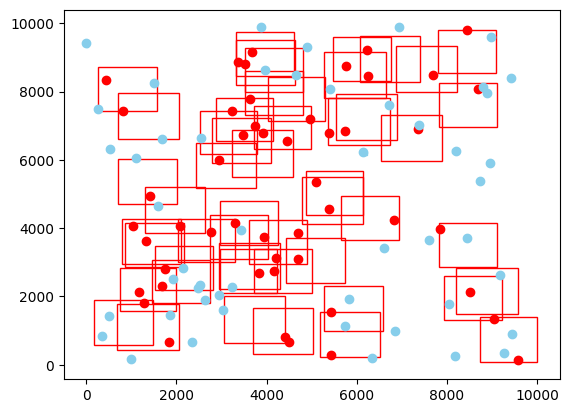

In [20]:
def view(env):
    "点とそれに対応する四角形を表示する"
    area = []
    for i, r in enumerate(env.rectangles):
        area.append((i, (r[1] - r[0]) * (r[3] - r[2])))
    area.sort(key=lambda x: x[1], reverse=False)
    area_ind_all = [i[0] for i in area]
    area_ind = area_ind_all[-50:]

    fig, ax = plt.subplots()
    for i in area_ind:
        now_color = matplotlib.cm.tab20(i)
        now_color = "red"
        x, y = env.coordinates[i]
        a, b, c, d = env.rectangles[i]
        ax.add_patch(plt.Rectangle((a, c), b - a, d - c, fill=False, edgecolor=now_color))
        ax.plot(x, y, "o", color=now_color)

    area_ind = area_ind_all[:50]
    for i in area_ind:
        now_color = matplotlib.cm.tab20(i)
        now_color = "skyblue"
        x, y = env.coordinates[i]
        a, b, c, d = env.rectangles[i]
        ax.add_patch(plt.Rectangle((a, c), b - a, d - c, fill=False, edgecolor=now_color))
        ax.plot(x, y, "o", color=now_color)

    plt.show()


view(env)

In [5]:
import copy

In [6]:
class UnionFind:
    def __init__(self, n):
        self.n = n
        self.parents = [-1] * n

    def find(self, x):
        if self.parents[x] < 0:
            return x
        else:
            self.parents[x] = self.find(self.parents[x])
            return self.parents[x]

    def union(self, x, y):
        x = self.find(x)
        y = self.find(y)

        if x == y:
            return

        if self.parents[x] > self.parents[y]:
            x, y = y, x

        self.parents[x] += self.parents[y]
        self.parents[y] = x

    def size(self, x):
        return -self.parents[self.find(x)]

    def same(self, x, y):
        return self.find(x) == self.find(y)

    def members(self, x):
        root = self.find(x)
        return [i for i in range(self.n) if self.find(i) == root]

    def roots(self):
        return [i for i, x in enumerate(self.parents) if x < 0]

    def group_count(self):
        return len(self.roots())

    def all_group_members(self):
        ret = dict()
        for i in range(self.n):
            r = self.find(i)
            if r in ret:
                ret[r].append(i)
            else:
                ret[r] = [i]
        return ret

    def __str__(self):
        return "\n".join("{}: {}".format(r, self.members(r)) for r in self.roots())


def kruskals_algorithm(edges, N):
    """最小全域木[クラスカル法] O(ElogV)
    edges : (c, a, b) 事前にソートしておくこと
    """
    uf = UnionFind(N)
    cost = 0
    ans_edges = []
    for edge in edges:
        c, a, b = edge
        if not uf.same(a, b):
            cost += c
            uf.union(a, b)
            ans_edges.append((a, b))
    return cost, ans_edges


def prim(graph: dict[int, list[tuple[int, int]]]) -> list[tuple[int, int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: dict[int, list[tuple[int, int]]], init_v: int, k: int, used_v: set[int]) -> list[tuple[int, int]]:
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = copy.copy(used_v)
    used.add(init_v)
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0
    while que:
        if len(ans_v) >= k:
            break
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt, cost_nxt in graph[to_v]:
            if nxt in used:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v, ans_cost

In [7]:
from collections import defaultdict

# 中心座標をもとにグラフを作成
graph = defaultdict(list)
for i in range(env.N):
    for j in range(env.N):
        if i == j:
            continue
        dist = (
            abs(env.cneter_points[i][0] - env.cneter_points[j][0]) ** 2
            + abs(env.cneter_points[i][1] - env.cneter_points[j][1]) ** 2
        )
        dist = dist**0.5
        graph[i].append((j, dist))
        graph[j].append((i, dist))

In [8]:
INF = 10**18

groups = [(i, g) for i, g in enumerate(env.G)]
groups = sorted(groups, key=lambda x: x[1], reverse=True)

ans_edges = [None for _ in range(len(groups))]
ans_v = [None for _ in range(len(groups))]

now_used = set()
for group_n, group_size in groups:
    now_cost = INF
    min_cost_ans = None
    for v in range(env.N):
        if v in now_used:
            continue
        prim_edges, prim_v, cost = prim_k(graph, v, group_size, now_used)
        if cost < now_cost:
            now_cost = cost
            min_cost_ans = prim_edges, prim_v
        break
    prim_edges, prim_v = min_cost_ans
    ans_edges[group_n] = prim_edges
    ans_v[group_n] = prim_v
    now_used.update(prim_v)

env.answer(ans_v, ans_edges, "../out/0000.txt")

In [9]:
# 点と全域木を表示
def view_edges(env, edges):
    fig, ax = plt.subplots()
    for i in range(env.N):
        x, y = env.coordinates[i]
        ax.plot(x, y, "o", color="black")
    for e in edges:
        x1, y1 = env.coordinates[e[0]]
        x2, y2 = env.coordinates[e[1]]
        ax.plot([x1, x2], [y1, y2], color="red")
    plt.show()

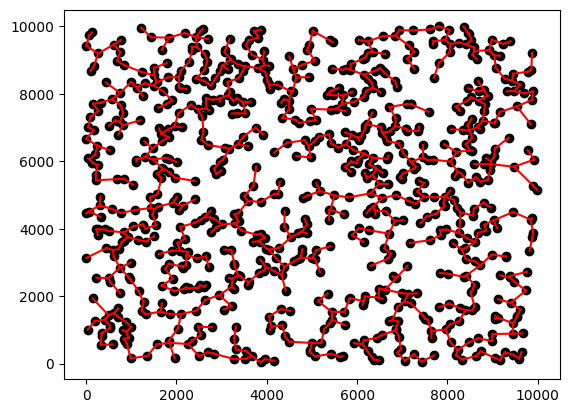

In [10]:
edges = []
for i in range(env.N):
    for j in range(env.N):
        if i == j:
            continue
        dist = (
            abs(env.coordinates[i][0] - env.coordinates[j][0]) ** 2
            + abs(env.coordinates[i][1] - env.coordinates[j][1]) ** 2
        )
        dist = dist**0.5
        edges.append((dist, i, j))

edges = sorted(edges, key=lambda x: x[0])
ans_cost, ans_edges = kruskals_algorithm(edges, env.N)
view_edges(env, ans_edges)

In [11]:
# area = []
# for r in env.rectangles:
#     area.append((r[1] - r[0]) * (r[3] - r[2]))

# sorted(area)